<a href="https://colab.research.google.com/github/lvjr3383/AI_Safety/blob/main/ml-basics/Part5_ML_Foundations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Foundations
### Part 5 of the ML Basics Series

Welcome back.

Python, NumPy, linear algebra, calculus, and PyTorch already gave us the pieces. This notebook is about what those pieces are *for*.

A program you write by hand looks like this:

```text
Rules + Data  →  Answer
```

You invent the rules. The computer applies them.

Machine learning flips that:

```text
Data + Answers  →  Model
```

You show examples. The computer finds the rule. Later:

```text
New Data + Model  →  Prediction
```

We will walk that loop in code:

**Data → Model → Prediction → Loss → Optimization → Evaluation → Generalization**

We will train real models, let some of them fail on purpose, and then ask why.

## What we'll build

A path, not a list to memorize:

1. Name the parts of a tiny dataset (`X` and `y`).
2. Hide some examples (a train/test split) so we can check whether the model learned.
3. Train a straight-line model and read the two numbers it found (`w` and `b`).
4. Measure how wrong it is (loss).
5. Watch a weight improve, one gradient step at a time.
6. Predict a choice instead of a number (classification).
7. See why "95% accurate" can still be an inefficient model.
8. Watch underfitting and overfitting on the same curved data.
9. Meet regularization as a response to overfitting.
10. Catch data leakage, the "too good to be true" score.
11. Run the loop on real housing data, then contrast sklearn with PyTorch.
12. A capstone classifier as a graduation check.

If you are new, run each cell as you go. If you have seen this material, skim the notes after each output. The code is the experiment. The markdown is someone sitting next to you.

## 1. Setup

Grab NumPy, pandas, matplotlib, and scikit-learn. sklearn will hide a lot of the training-loop machinery we wrote by hand in Part 4. We will meet each tool when we use it.

We also freeze the random number generator. Later cells draw noise, random splits, and random starting weights. Without a seed, every re-run would move the plots a little, and it would be harder to talk about "the" result.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

np.random.seed(42)
print("Random seed fixed at 42.")

Random seed fixed at 42.


There it is: `Random seed fixed at 42.` From here on, the random draws in this notebook repeat. The ideas do not depend on the seed. The seed just keeps the pictures still while we talk about them.

## 2. What is machine learning?

Three names we will use constantly:

- **`X`**: the clues (features). Hours studied, income, pixel values.
- **`y`**: the answer we want (the target). Exam score, house price, pass/fail.
- **model**: the learned relationship between `X` and `y`. Often just a handful of numbers, like a weight and a bias.

We are not going to define this in the abstract. We are going to look at five rows. Each `x` has a matching `y`. That pairing is the raw material of supervised learning.

In [ ]:
# Feature: hours studied
hours_studied = np.array([1, 2, 3, 4, 5])

# Target: exam score
exam_scores = np.array([52, 57, 65, 72, 81])

print("Hours studied:", hours_studied)
print("Exam scores:  ", exam_scores)

Hours studied: [1 2 3 4 5]
Exam scores:   [52 57 65 72 81]


Five hours values, five scores. As hours go up, scores go up. A human looking at this would already guess there is a pattern.

We have not trained anything. We are just looking. A picture makes the pattern harder to miss.

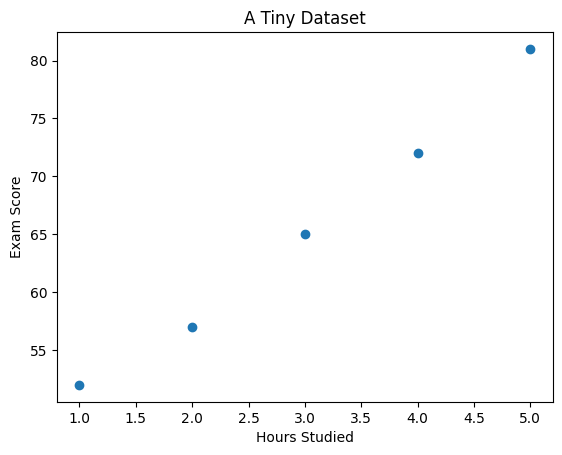

In [ ]:
plt.scatter(hours_studied, exam_scores)
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("A Tiny Dataset")
plt.show()

The points trend upward. That is the kind of pattern a model can learn, not a perfect line, just a direction.

If someone studied 6 hours, you would expect a score *higher* than 81, not lower. You already have a model in your head. Machine learning is how we get a computer to form one from examples instead of from a rule we typed.

**Pause here (no coding):**

1. Which variable is the **feature** (`X`)?
2. Which variable is the **target** (`y`)?
3. If someone studied 6 hours, would you expect the score to be higher or lower than 81?
4. Would you trust a rule based on five points for a real exam-prep product? Why or why not?

## 3. Features and targets

ML data is stored as a table of numbers:

```text
One row    = one example
One column = one feature
```

sklearn (and PyTorch) want `X` as a 2D array of shape `(n_examples, n_features)`, even when there is only one feature. A 1D array of length 5 looks like 5 features of one example. The extra column dimension says: 5 examples, one feature each.

Same hours and scores as above. We just store them the way the libraries expect. Watch `.shape`.

In [ ]:
# X is 2D even with one feature: (n_examples, n_features)
X = np.array([
    [1],
    [2],
    [3],
    [4],
    [5],
])

y = np.array([52, 57, 65, 72, 81])

print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("X:")
print(X)

X shape: (5, 1)
y shape: (5,)

X:
[[1]
 [2]
 [3]
 [4]
 [5]]


`X` has shape `(5, 1)`: 5 examples, 1 feature.
`y` has shape `(5,)`: 5 answers.

The rest of this notebook is this loop, in code:

1. Collect data
2. Choose features (`X`) and the target (`y`)
3. Split into train and test
4. Train a model
5. Make predictions
6. Measure how wrong they are
7. Improve, then check **generalization**, whether it still works on examples it never saw while learning

## 4. Why we split data

If you give someone the answers while they study, and then test them on the **exact same questions**, you have not measured whether they learned. You measured whether they can copy.

So we hide some examples.

- **Train**: what the model is allowed to study
- **Validation**: a practice test used to make choices (we will mention it; we will not lean on it much yet)
- **Test**: the final exam, seen once at the end

We want to know whether the model works on examples it never saw while learning. That is called **generalization**. In this notebook we will mostly use a **train / test** split.

A different toy than the exam scores: 20 points that roughly follow `y ≈ 3x`, with a little noise so it looks like real measurements. Then we hide 25%. Before you run the cell, guess: 20 × 0.25 = how many test examples?

In [ ]:
# 20 examples of a noisy straight line: y ≈ 3x
X = np.arange(1, 21).reshape(-1, 1)
y = 3 * X.squeeze() + np.random.normal(0, 3, size=20)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("First 5 y values:", np.round(y[:5], 2))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
)

print("Training examples:", len(X_train))
print("Test examples:    ", len(X_test))

X shape: (20, 1)
y shape: (20,)
First 5 y values: [ 4.49  5.59 10.94 16.57 14.3 ]
Training examples: 15
Test examples:     5


Twenty examples, one feature, noisy `y`. The first few `y` values are not exactly `3, 6, 9, …`. The noise is the point. Real data is never a perfect line.

15 training examples, 5 test examples. 20 × 0.25 = 5. The split did the arithmetic we expected.

`random_state=42` makes the split the same every time, same idea as the seed. A picture of *which* points were hidden is more memorable than the counts.

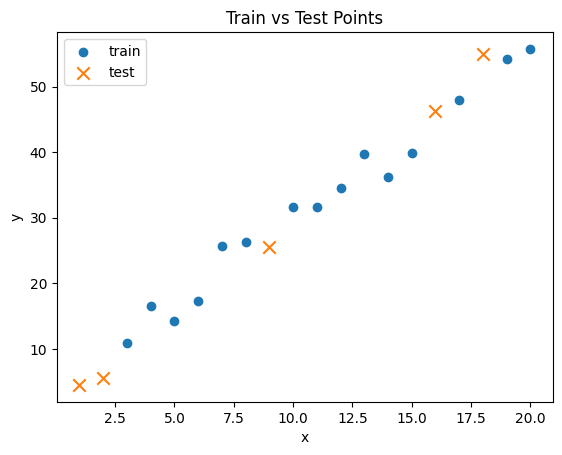

In [ ]:
plt.scatter(X_train, y_train, label="train")
plt.scatter(X_test, y_test, marker="x", s=80, label="test")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Train vs Test Points")
plt.legend()
plt.show()

The `x` marks sit on the same overall trend. They are not a different universe. They were just not shown to the model. Nothing later should touch those test points until we evaluate.

**Try this:** change `test_size` from `0.25` to `0.20`. Before re-running, predict how many test examples you will get (20 × 0.20 = ?). Then put it back to `0.25` before you continue. You are not going to break anything.

## 5. Two common types of supervised learning

**Supervised** means we have answers (`y`) for the training examples.

**Regression** predicts a number. House price. Temperature. Delivery time. Exam score. Anything where "a bit too high" and "a bit too low" both make sense.

**Classification** predicts a category. Spam / not spam. Pass / fail. Cat / dog. The answer is a *choice*, not a point on a ruler.

The type of `y` decides which family of models and metrics we use. We will do regression first, then classification. The loop is the same.

In [ ]:
# Regression targets are numbers on a scale
regression_target = np.array([120000, 180000, 250000])

# Classification targets are category labels (here 0 and 1)
classification_target = np.array([0, 1, 0])

print("Regression targets:    ", regression_target)
print("Classification targets:", classification_target)

Regression targets:     [120000 180000 250000]
Classification targets: [0 1 0]


`120000, 180000, 250000` are amounts. Averaging them would mean something.

`0, 1, 0` are *names* for two classes, not amounts. Averaging them into `0.33` is not a third class. (A number between 0 and 1 *can* be a probability later. That is different.)

Look at `y` first. It tells you which tools to reach for.

**For each scenario, write regression or classification:**

1. Predict tomorrow's high temperature.
2. Predict whether an email is spam.
3. Predict a used car's price.
4. Predict if a transaction is fraudulent.
5. Predict how many minutes a delivery will take.

## 6. Linear regression

This is your first real model. The idea is a line:

```text
y = w x + b
```

- `x`: the input (hours studied)
- `w`: the **weight** (how much `y` changes when `x` goes up by 1)
- `b`: the **bias** (where the line starts)
- `y`: the prediction

sklearn finds `w` and `b` for you. `.fit()` looks easy after the training loop in Part 4 because sklearn is doing that search behind the scenes.

A slightly larger exam-score table this time. We hide a few rows, then let sklearn search using *only* the training rows.

In [ ]:
# Tiny exam-score data
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8]])
y = np.array([55, 58, 64, 68, 74, 78, 83, 88])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# .fit() = "search for the best w and b on the training data"
model = LinearRegression()
model.fit(X_train, y_train)

print("Train size:", len(X_train), " Test size:", len(X_test))
print("Weight (w):", model.coef_)
print("Bias   (b):", model.intercept_)

Train size: 6  Test size: 2
Weight (w): [4.74]
Bias   (b): 49.88000000000001


8 examples, 6 train, 2 test. Small on purpose so we can still see every number.

A weight around **4.74** means that, according to this model, adding one more hour of study increases the predicted score by roughly 4.7 points. The bias, about **49.9**, is where the line starts: the predicted score at 0 hours.

The learned rule is:

```text
prediction = 4.74 × hours + 49.88
```

The model has not looked at `X_test` yet. Let's compute one prediction by hand, then ask sklearn to do the same calculation. If they match, `.predict()` is not a second algorithm. It is that line.

Manual prediction for 6 hours: 78.32
sklearn prediction for 6 hours: [78.32]


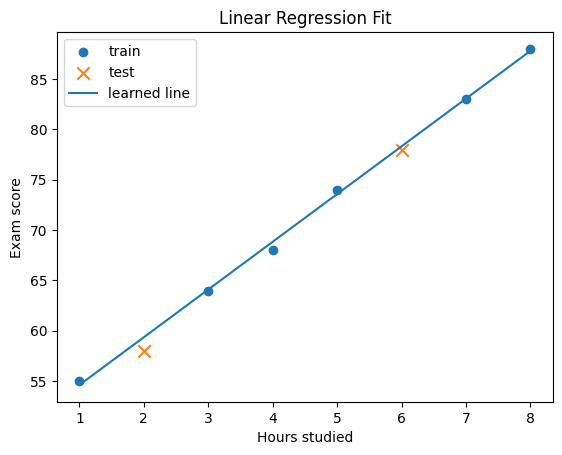

In [ ]:
x_new = 6
manual_prediction = model.coef_[0] * x_new + model.intercept_

print("Manual prediction for 6 hours:", manual_prediction)
print("sklearn prediction for 6 hours:", model.predict([[6]]))

# Draw the learned line across the full x range
x_line = np.linspace(1, 8, 50).reshape(-1, 1)
y_line = model.predict(x_line)

plt.scatter(X_train, y_train, label="train")
plt.scatter(X_test, y_test, marker="x", s=80, label="test")
plt.plot(x_line, y_line, label="learned line")
plt.xlabel("Hours studied")
plt.ylabel("Exam score")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()

They match: **78.32** both ways. `.predict()` is that line, applied to every row you give it.

The line on the plot *is* the model. Training dots, test `x` marks, and a straight line that follows the upward trend. Every prediction we make from here is a point on that line.

**.fit()** found `w` and `b` from training data only. **.coef_** is the weight. **.intercept_** is the bias.

**Try this:** using the printed weight and bias, predict the score for `x = 9` by hand (`4.74 × 9 + 49.88`). Check with `model.predict([[9]])`. Do the two numbers match?

## 7. How wrong is the model?

A prediction by itself tells us very little. How do we know whether it was good?

```text
Actual value:  80
Prediction:    76
Error = 4
```

One error is not enough. We need a single number for the whole test set. That number is called **loss** (or a metric).

Ask the model for predictions on the *test* rows, the ones it did not train on. Then summarize the mistakes with **MSE** (mean squared error):

```text
MSE = average( (actual - predicted)² )
```

Squaring does two things: negatives become positive, and large mistakes grow faster than small ones. We will compute MSE by hand first, then let sklearn do it.

In [ ]:
predictions = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": np.round(predictions, 2),
})
print(comparison)

errors = y_test - predictions
squared_errors = errors ** 2
mse_manual = squared_errors.mean()

print("Errors:         ", np.round(errors, 2))
print("Squared errors: ", np.round(squared_errors, 2))
print("MSE (manual):   ", mse_manual)
print("MSE (sklearn):  ", mean_squared_error(y_test, predictions))

   Actual  Predicted
0      58      59.36
1      78      78.32
Errors:          [-1.36 -0.32]
Squared errors:  [1.85 0.1 ]
MSE (manual):    0.9760000000000066
MSE (sklearn):   0.9760000000000066


Two test examples: actual **58** vs predicted **59.36**, and actual **78** vs predicted **78.32**. Small misses.

Errors about **-1.36** and **-0.32**. Squared, about **1.85** and **0.10**. Average: **MSE ≈ 0.976**. sklearn prints the same **0.976**. The library is a shortcut, not a different idea.

A loss of about 1 exam-point-squared on this tiny test set means the line is doing well here. Loss is how we *measure* "doing well." Next: how the model *uses* that information.

**MAE** (mean absolute error) is the average of `|actual - predicted|`. From the errors `-1.36` and `-0.32`, compute MAE by hand (average of the absolute values). Then check with `mean_absolute_error(y_test, predictions)`.

## 8. How does the model improve?

A model predicts, calculates loss, changes its parameters, and tries again.

**Gradient descent** is: take a step in the direction that reduces the error.

We will do this for **one** weight, by hand, so you can see the loop. sklearn hides this loop inside `.fit()`. PyTorch's autograd computes the gradient for you. Same idea, three interfaces.

Toy problem: we want `weight × 2 ≈ 10`, so the true weight is 5. We start from a terrible guess (`1.0`) and take ten steps. Watch the loss column. Guess whether the weight will climb toward 5, and whether the loss will fall quickly or crawl.

In [ ]:
# Toy problem: learn weight so that  weight * 2  ≈  10
# True weight is 5.
x = 2
y_true = 10

weight = 1.0          # a bad starting guess
learning_rate = 0.1   # step size

print("Starting weight:", weight)

history = []

for step in range(10):
    y_pred = weight * x
    loss = (y_true - y_pred) ** 2

    # Derivative of (y_true - w*x)^2  with respect to w
    gradient = -2 * x * (y_true - y_pred)
    weight = weight - learning_rate * gradient

    history.append((step, weight, loss))
    print(f"step {step:2d}  weight={weight:7.3f}  loss={loss:8.3f}")

Starting weight: 1.0
step  0  weight=  4.200  loss=  64.000
step  1  weight=  4.840  loss=   2.560
step  2  weight=  4.968  loss=   0.102
step  3  weight=  4.994  loss=   0.004
step  4  weight=  4.999  loss=   0.000
step  5  weight=  5.000  loss=   0.000
step  6  weight=  5.000  loss=   0.000
step  7  weight=  5.000  loss=   0.000
step  8  weight=  5.000  loss=   0.000
step  9  weight=  5.000  loss=   0.000


Starting weight: **1.0**. True answer: **5**. Learning rate: **0.1**.

- Step 0: weight jumps from 1.0 to **4.20**, loss **64**.
- Step 1: weight **4.84**, loss already **2.56**.
- By step 5 the weight is **5.000** and the loss is gone.

Read one loop:

- `y_pred = weight * x`: the current guess
- `loss`: how wrong
- `gradient`: which way to move `weight`
- `weight = weight - learning_rate * gradient`: take a step

Nothing in sklearn's `.fit()` is a different kind of magic. It is this loop, with more parameters and a better optimizer.

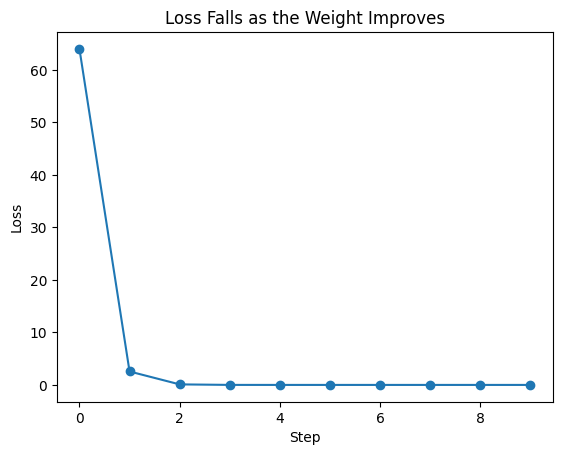

In [ ]:
steps = [h[0] for h in history]
losses = [h[2] for h in history]

plt.plot(steps, losses, marker="o")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss Falls as the Weight Improves")
plt.show()

The curve falls off a cliff, then lies flat. Big mistakes at the start, then nothing left to fix.

**Try this:** set `learning_rate` to `0.01` and re-run the loop. Does the curve crawl? Set it to `0.5`. Does it overshoot or bounce? Put it back to `0.1` before you continue.

## 9. Logistic regression

What if the answer is not a number like `$250,000`, but a choice such as pass/fail?

```text
Will a student pass?
0 = No
1 = Yes
```

Linear regression can spit out values like `-0.4` or `1.7`. Those do not behave like probabilities. We want a number between **0 and 1**: how sure are we that this is a pass?

The **sigmoid** function squashes any number into (0, 1). An S-shaped curve: far left almost 0, far right almost 1, middle 0.5.

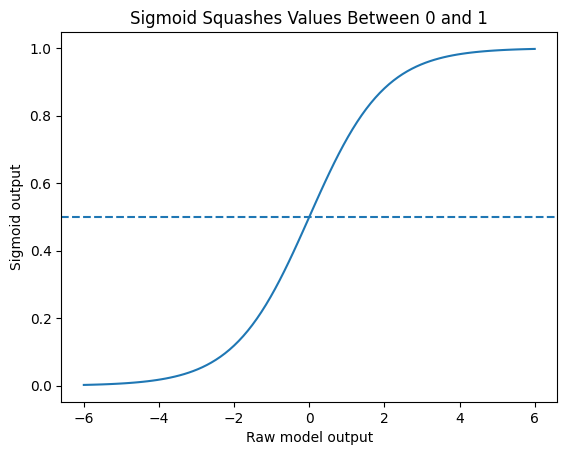

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

values = np.linspace(-6, 6, 100)
outputs = sigmoid(values)

plt.plot(values, outputs)
plt.xlabel("Raw model output")
plt.ylabel("Sigmoid output")
plt.title("Sigmoid Squashes Values Between 0 and 1")
plt.axhline(0.5, linestyle="--")
plt.show()

The dashed line is the common threshold:

```text
probability >= 0.5  →  class 1 (pass)
probability <  0.5  →  class 0 (fail)
```

The raw model can still think in "linear regression language." Sigmoid is the translator into probability language.

Now a tiny pass/fail table on hours studied. Hours 1-4 fail (`0`). Hours 5-8 pass (`1`). A clean pattern, on purpose, so the probabilities later are easy to read. Same split-and-fit workflow as linear regression.

In [ ]:
# Hours studied → pass (1) or fail (0)
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8]])
y = np.array([0, 0, 0, 0, 1, 1, 1, 1])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

clf = LogisticRegression()
clf.fit(X_train, y_train)

print("X:", X.squeeze())
print("y:", y)
print("Classes:", clf.classes_)
print("Predicted class:      ", clf.predict(X_test))
print("Predicted probability:\n", np.round(clf.predict_proba(X_test), 3))
print("True labels:          ", y_test)

X: [1 2 3 4 5 6 7 8]
y: [0 0 0 0 1 1 1 1]
Classes: [0 1]
Predicted class:       [0 1]
Predicted probability:
 [[0.936 0.064]
 [0.201 0.799]]
True labels:           [0 1]


The labels flip from 0 to 1 between 4 and 5 hours. `Classes: [0 1]`. The model knows the two names it is allowed to predict.

Predicted classes: **`[0 1]`**. True labels: **`[0 1]`**. Both test rows correct.

Probabilities:

- First test example: **0.936** for class 0, **0.064** for class 1 → confidently fail
- Second: **0.201** for class 0, **0.799** for class 1 → reasonably confidently pass

`predict` picks the class with the larger probability (threshold 0.5). `predict_proba` is the richer object. We will need it when we talk about thresholds later.

**Try this:** predict for `[[4.5]]`, right on the fence. Print both `predict` and `predict_proba`. Which class wins, and how confident is the model?

## 10. Accuracy is useful, but it can lie

**Accuracy** answers one question: *how often was the model right overall?*

That sounds like the whole story. It isn't.

Try this in your head: 6 predictions, 4 of them correct. What is the accuracy? Keep that 4/6 in mind. Then we will ask a better question: *which* mistakes did we make?

In [ ]:
y_true = np.array([1, 1, 1, 1, 0, 0])
y_pred = np.array([1, 1, 0, 1, 0, 1])

print("True:     ", y_true)
print("Predicted:", y_pred)
print("Accuracy: ", accuracy_score(y_true, y_pred))

True:      [1 1 1 1 0 0]
Predicted: [1 1 0 1 0 1]
Accuracy:  0.6666666666666666


Accuracy **0.667**, four out of six. Fine. But it does not say **which** mistakes we made.

| | Predicted 1 | Predicted 0 |
|---|---|---|
| **Actually 1** | True Positive (TP) | False Negative (FN) |
| **Actually 0** | False Positive (FP) | True Negative (TN) |

- **False positive**: the model cried wolf
- **False negative**: the model missed a real case

A **confusion matrix** is that table, filled in with counts. sklearn orders rows and columns as class 0, then class 1:

```text
[[ TN  FP ]
 [ FN  TP ]]
```

[[1 1]
 [1 3]]


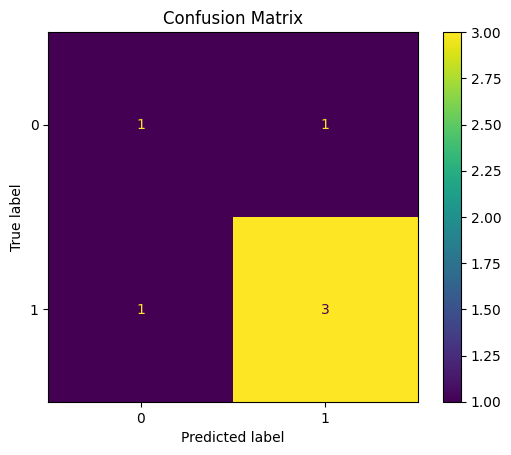

Accuracy:  0.6666666666666666
Precision: 0.75
Recall:    0.75
F1:        0.75


In [ ]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

print("Accuracy: ", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:   ", recall_score(y_true, y_pred))
print("F1:       ", f1_score(y_true, y_pred))

The matrix printed `[[1 1] [1 3]]`:

- 1 true negative
- 1 false positive (cried wolf)
- 1 false negative (missed a real 1)
- 3 true positives

Accuracy treated all four-out-of-six successes as equal. The matrix shows the two failures were *different kinds*.

Accuracy **0.67**, precision **0.75**, recall **0.75**, F1 **0.75**.

**Precision** = TP / (TP + FP). Of the 4 times we said "1" (3 TP + 1 FP), we were right 3 times.

**Recall** = TP / (TP + FN). Of the 4 actual ones, we found 3.

**F1** balances them.

Now the trap. Imagine 100 people: 95 healthy, 5 sick. A model that predicts **everyone healthy** has accuracy **95%**. It never finds a sick person. Recall for "sick" is 0. That looks impressive on a dashboard. It is useless for the thing we care about.

> A metric is only useful if it measures the kind of mistake we actually care about.

If missing a sick patient is the disaster, watch **recall**. If false alarms are the disaster, watch **precision**. Accuracy does not know which disaster you meant.

**Try this:** change `y_pred` so that every true 1 is caught (recall = 1.0). You may create extra false positives. Recompute precision and recall. What happened to precision?

## 11. Evaluating regression models

Classification had accuracy, precision, recall, F1. Regression has a different trio.

**MAE**: how big is a typical mistake, in the same units as `y`?

**MSE**: if we square the mistakes, how much do the *large* ones dominate?

**R²**: how much of the variation in `y` did we capture? `1.0` is a perfect fit. `0.0` is "no better than predicting the mean every time."

In [ ]:
y_true = np.array([100, 150, 200, 250])
y_pred = np.array([110, 140, 205, 230])

print("MAE:", mean_absolute_error(y_true, y_pred))
print("MSE:", mean_squared_error(y_true, y_pred))
print("R²: ", r2_score(y_true, y_pred))

MAE: 11.25
MSE: 156.25
R²:  0.95


MAE **11.25**: on average we are about 11 units off.
MSE **156.25**: looks scarier because it is squared. That is expected.
R² **0.95**: the model captured most of the pattern.

MAE is the one you can say out loud to a human. MSE is the one that *hurts* more when one prediction is a disaster. R² is the "did we learn the trend at all?" check.

**Try this:** change the last prediction from `230` to `50` (a terrible miss). Re-run MAE and MSE. Which metric jumped more? Why?

## 12. When models learn too little or too much

These words get thrown around. We are going to *see* them.

**Underfitting**: the model's view of the world is too simple. It fails on training data **and** on new data. Also called **high bias**.

**Good fit**: it captures the useful pattern, not the noise.

**Overfitting**: the model learns the training examples *too* well, including their noise and quirks. Great on training data, poor on new data. Also called **high variance**.

```text
High Bias     →  Underfitting
High Variance →  Overfitting
```

We will give the **same** curved, noisy data to three models: a straight line (degree 1), a quadratic (degree 2), and an extremely wiggly polynomial (degree 15).

Before you run anything, predict what each line will look like:

- Degree 1: a slash that misses the U?
- Degree 2: a U that follows the cloud?
- Degree 15: a line that chases every training dot?

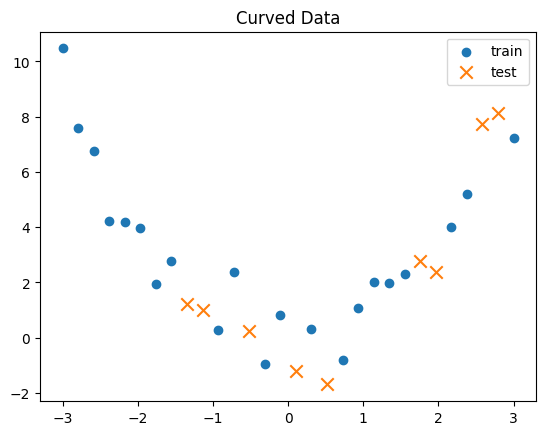

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# A noisy U-shape
X = np.linspace(-3, 3, 30).reshape(-1, 1)
y = (X.squeeze() ** 2) + np.random.normal(0, 1, 30)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

plt.scatter(X_train, y_train, label="train")
plt.scatter(X_test, y_test, marker="x", s=80, label="test")
plt.title("Curved Data")
plt.legend()
plt.show()


def fit_poly(degree):
    # PolynomialFeatures expands x into [1, x, x², ..., x^degree]
    # then LinearRegression fits a line in that expanded space.
    return make_pipeline(
        PolynomialFeatures(degree, include_bias=False),
        LinearRegression(),
    ).fit(X_train, y_train)


def plot_poly(degree, title):
    model_d = fit_poly(degree)
    xs = np.linspace(-3.2, 3.2, 200).reshape(-1, 1)
    plt.scatter(X_train, y_train, label="train")
    plt.scatter(X_test, y_test, marker="x", s=80, label="test")
    plt.plot(xs, model_d.predict(xs), label=f"degree {degree}")
    plt.title(title)
    plt.legend()
    plt.show()
    return model_d

A noisy U. Training dots and test `x` marks on the same curve. The test marks are the judge for whatever line we draw next.

First experiment: a straight line on a U-shape. This should be a bad idea.

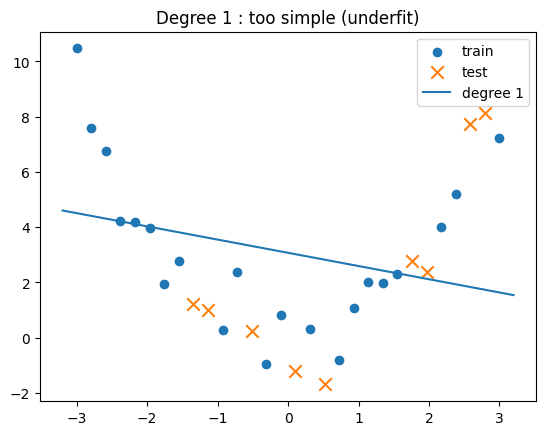

In [ ]:
model_under = plot_poly(1, "Degree 1 : too simple (underfit)")

A straight line cannot follow a U. It cuts through the middle and misses both arms. Training *and* test will both look bad. That stubborn "the world is a line" assumption is **high bias**.

The true pattern was `x²`, so degree 2 is the right amount of flexibility. Guess: the line should look like a U, not a slash and not a scribble.

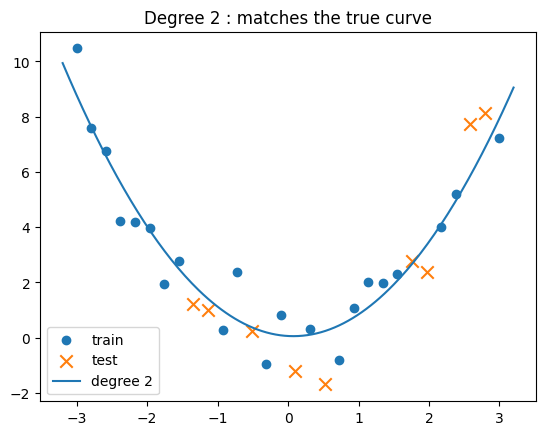

In [ ]:
model_ok = plot_poly(2, "Degree 2 : matches the true curve")

Degree 2 follows the curve without leaping at every noisy training point.

Now the trap. Degree 15 can wiggle through almost anything. Will the training dots sit almost on the line? What will happen in the gaps, and on the test `x` marks?

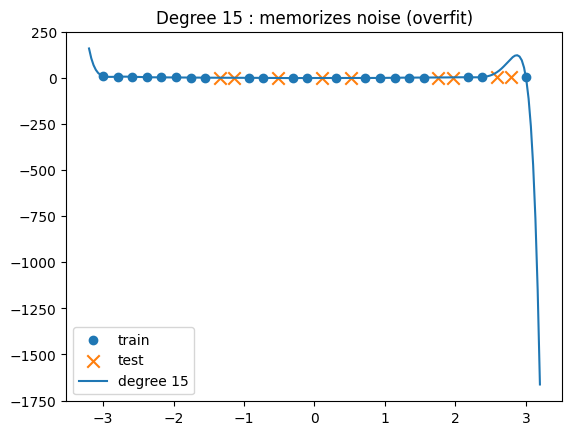

In [ ]:
model_over = plot_poly(15, "Degree 15 : memorizes noise (overfit)")

The wiggly line chases every training point. That twitchy sensitivity to the exact training sample is **high variance**.

Pictures first, numbers second. Watch for:

- High train **and** high test → underfit (high bias)
- Low train, high test → overfit (high variance)
- Both reasonably low → good fit

In [ ]:
def report(name, model_d):
    tr = mean_squared_error(y_train, model_d.predict(X_train))
    te = mean_squared_error(y_test, model_d.predict(X_test))
    print(f"{name:12s}  train MSE={tr:6.2f}  test MSE={te:6.2f}")


report("degree 1", model_under)
report("degree 2", model_ok)
report("degree 15", model_over)

degree 1      train MSE=  7.57  test MSE= 15.25
degree 2      train MSE=  0.74  test MSE=  1.35
degree 15     train MSE=  0.36  test MSE=1131.65


| Model | Train MSE | Test MSE | Reading |
|-------|-----------|----------|---------|
| Degree 1 | **7.57** | **15.25** | bad everywhere: underfit, high bias |
| Degree 2 | **0.74** | **1.35** | both low: good fit |
| Degree 15 | **0.36** | **1131.65** | almost perfect on train, a disaster on test: overfit, high variance |

Degree 15 did not "learn the U better." It memorized the noise, then fell apart the moment the points were slightly different.

Comparing train vs test error is how you see the difference. A fantastic training score can be a warning. If you can look at a train/test pair and say "too simple" vs "too eager," you have the idea that matters in practice.

**Try this:** fit degree `4`, then `8`. Watch train and test MSE. Where does overfitting start to show?

For each pair, say **underfit**, **overfit**, or **good fit**:

1. train MSE = 40, test MSE = 42
2. train MSE = 0.2, test MSE = 35
3. train MSE = 3, test MSE = 4

## 13. Regularization: keeping models under control

We just watched a model become too eager. Can we tell it, "fit the data, but don't go crazy"?

That request has a name: **regularization**. It discourages a model from relying on extreme weights.

- **L2 (Ridge)**: large weights get a penalty, so they shrink.
- **L1 (Lasso)**: some weights may be pushed all the way toward zero (the feature is ignored).

We will build data where **only the first two features actually matter** (true weights `3` and `-2`, the rest `0`). Then fit ordinary linear regression, Ridge, and Lasso on the same split.

Watch the unused coefficients. Linear regression will try to use every feature a little. Ridge should shrink the junk. Lasso should often drive the junk to (almost) zero.

In [ ]:
from sklearn.linear_model import Ridge, Lasso

# 40 examples, 8 features. Only the first 2 features actually matter.
n, p = 40, 8
X = np.random.normal(size=(n, p))
true_w = np.array([3.0, -2.0, 0, 0, 0, 0, 0, 0])
y = X @ true_w + np.random.normal(0, 0.5, size=n)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

lin = LinearRegression().fit(X_train, y_train)
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=0.15).fit(X_train, y_train)

print("True weights:          ", true_w)
print("Linear Regression coef:", np.round(lin.coef_, 2))
print("Ridge coef:            ", np.round(ridge.coef_, 2))
print("Lasso coef:            ", np.round(lasso.coef_, 2))

True weights:           [ 3. -2.  0.  0.  0.  0.  0.  0.]
Linear Regression coef: [ 3.07 -1.98 -0.11 -0.46 -0.1   0.01 -0.02 -0.02]
Ridge coef:             [ 2.96 -1.87 -0.04 -0.38 -0.13  0.05  0.03 -0.06]
Lasso coef:             [ 2.97 -1.68  0.   -0.05 -0.    0.    0.   -0.  ]


True weights: **`[3, -2, 0, 0, 0, 0, 0, 0]`**.

What the three models did with the junk features (the last six numbers):

- **Linear regression:** `[-0.11, -0.46, -0.10, 0.01, -0.02, -0.02]`. It sprinkled little weights on unused features.
- **Ridge:** smaller junk, first two still near 3 and -2.
- **Lasso:** `[-0.05, 0, 0, 0, 0, 0]` on the unused side. It ignored them.

`alpha` is the strength of the penalty. Bigger `alpha` means a stronger push toward small weights.

In neural networks, **dropout** is another regularization trick: randomly ignore some units during training so the network cannot rely on any single one. We will return to dropout in Part 7.

**Try this:** set `Ridge(alpha=10)` and `Lasso(alpha=0.5)` and re-fit. What happens to the coefficients? Set both `alpha` values very small (close to 0). Do they start to look like Linear Regression? Put the original `alpha` values back.

## 14. Good models need good data

Before fancy models, look at the data: missing values, wild outliers, features on totally different scales, features that do not mean anything, and **target leakage**, a feature that already contains the answer.

A fantastic score can sometimes be evidence that something is wrong.

### Data leakage

Leakage is accidentally giving the model information it would not legitimately have when making a real prediction.

Imagine predicting whether a student **passed**, using hours studied, attendance, and final exam score. The final exam score *is* the answer. The model is not learning to predict. It is reading the key.

Two models on the same students: one gets hours studied **and** a leaked exam score that is basically the label in disguise. One gets hours studied only. Which accuracy will look more impressive? Which one would you trust in production?

In [ ]:
# Honest features + a leaked copy of the label
hours = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)
passed = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])
exam_score = passed * 90 + (1 - passed) * 40   # leaked: almost the label itself

X_leaky = np.column_stack([hours, exam_score])
X_honest = hours.reshape(-1, 1)
y = passed

Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_leaky, y, test_size=0.3, random_state=42
)
Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    X_honest, y, test_size=0.3, random_state=42
)

leaky = LogisticRegression().fit(Xl_train, yl_train)
honest = LogisticRegression().fit(Xh_train, yh_train)

print("Accuracy WITH leaked exam score:", accuracy_score(yl_test, leaky.predict(Xl_test)))
print("Accuracy WITHOUT leaked score:  ", accuracy_score(yh_test, honest.predict(Xh_test)))

Accuracy WITH leaked exam score: 1.0
Accuracy WITHOUT leaked score:   0.6666666666666666


Accuracy **WITH** leaked exam score: **1.0**
Accuracy **WITHOUT** leaked score: **0.667**

The leaked model looks "better." It is not smarter. It cheated. A lower, honest score can be the more trustworthy model. The 1.0 is the warning, not the victory.

> A fantastic score can sometimes be evidence that something is wrong.

### Preprocessing must learn from training data only

Scaling is a common step: subtract the mean, divide by the standard deviation. It is a good idea. It is also a way to leak if you are careless.

**Wrong**

```python
scaler.fit(all_data)   # peeked at the test set
```

**Right**

```python
scaler.fit(X_train)    # statistics come from train only
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)
```

Fit on training data. Transform training data. Transform test data. The test set must remain unseen information. It does not get a vote on the mean.

The next cell reuses the 8-feature data from the Ridge example. Watch for train-feature means near 0 (we fitted on train). Test-feature means should *not* be forced to 0 (we did not fit on test).

In [ ]:
from sklearn.preprocessing import StandardScaler

# Demo on the 8-feature data from the Ridge cell
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train mean per feature (should be ~0):")
print(np.round(X_train_s.mean(axis=0), 3))
print("Test mean per feature (not forced to 0 : we did not fit on test):")
print(np.round(X_test_s.mean(axis=0), 3))

Train mean per feature (should be ~0):
[-0.  0.  0. -0. -0. -0.  0.  0.]
Test mean per feature (not forced to 0 : we did not fit on test):
[-0.192 -0.192 -0.057  0.341 -0.256 -0.117  0.196 -0.008]


Train means: all **~0**. That is what `fit_transform` on train does.

Test means: **not** zero. Values like `-0.19`, `0.34`, `-0.26`. We applied the *training* ruler to the test set. We did not let the test set help draw the ruler.

**Which of these is leakage? Write leak or ok.**

1. Predicting hospital readmission using "number of previous visits."
2. Predicting whether a loan defaults using "amount already written off after default."
3. Predicting house price using "number of bedrooms."

## 15. Putting everything together

Until now we have mostly used tiny datasets so we could see every moving part. Let's do the same workflow with real data.

Our goal is not to win a housing prediction competition. It is to understand the workflow. First look at what you actually have. Never throw a dataset straight into a model.

In [ ]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("Shape:", df.shape)
print(df.columns.tolist())
print()
print(df.describe().round(2).T.head(8))
df.head()

Shape: (20640, 9)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

              count     mean      std     min     25%      50%      75%  \
MedInc      20640.0     3.87     1.90    0.50    2.56     3.53     4.74   
HouseAge    20640.0    28.64    12.59    1.00   18.00    29.00    37.00   
AveRooms    20640.0     5.43     2.47    0.85    4.44     5.23     6.05   
AveBedrms   20640.0     1.10     0.47    0.33    1.01     1.05     1.10   
Population  20640.0  1425.48  1132.46    3.00  787.00  1166.00  1725.00   
AveOccup    20640.0     3.07    10.39    0.69    2.43     2.82     3.28   
Latitude    20640.0    35.63     2.14   32.54   33.93    34.26    37.71   
Longitude   20640.0  -119.57     2.00 -124.35 -121.80  -118.49  -118.01   

                 max  
MedInc         15.00  
HouseAge       52.00  
AveRooms      141.91  
AveBedrms      34.07  
Population  35682.00  
AveOccup     1243.33  
Latitude       41.95  
Longitu

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


**20,640** rows, **9** columns. Each row is a district.

Columns: `MedInc`, `HouseAge`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup`, `Latitude`, `Longitude`, `MedHouseVal`.

The target is **`MedHouseVal`**: median house value, in units of $100,000s. Everything else is a feature: income, house age, rooms, location.

Median income averages about **3.87**, house age about **29** years. You do not need to memorize the table. You need the habit: look before you fit.

Before you run the next cell: 20,640 × 0.2 ≈ how many test rows?

In [ ]:
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, " Test:", X_test.shape)

housing_model = LinearRegression()
housing_model.fit(X_train, y_train)

y_hat = housing_model.predict(X_test)

print("MAE:", round(mean_absolute_error(y_test, y_hat), 3))
print("MSE:", round(mean_squared_error(y_test, y_hat), 3))
print("R²: ", round(r2_score(y_test, y_hat), 3))

Train: (16512, 8)  Test: (4128, 8)
MAE: 0.533
MSE: 0.556
R²:  0.576


Train **(16512, 8)**, test **(4128, 8)**. Eight features, thousands of rows.

MAE **0.533**: about 0.53 × $100,000 ≈ **$53,000** off, on average.
MSE **0.556**: squared units, as usual.
R² **0.576**: the model explains a bit more than half the variation. Better than guessing the mean. Not a housing-competition winner.

That is useful signal *and* plenty of leftover error. Both can be true. A few individual districts, then a scatter of actual vs predicted, make that concrete.

    Actual  Predicted
0  0.47700      0.719
1  0.45800      1.764
2  5.00001      2.710
3  2.18600      2.839
4  2.78000      2.605
5  1.58700      2.012
6  1.98200      2.646
7  1.57500      2.169


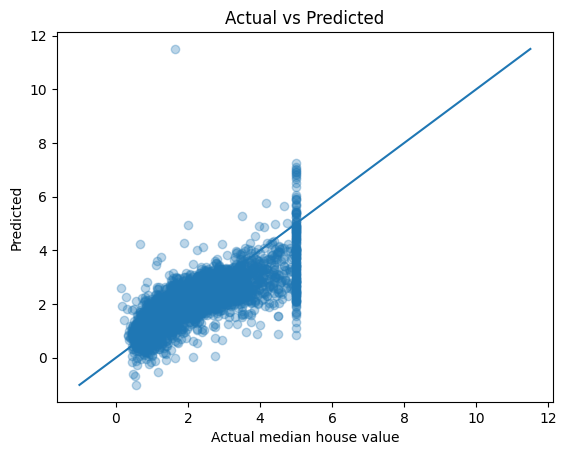

In [ ]:
sample = pd.DataFrame({
    "Actual": y_test.to_numpy()[:8],
    "Predicted": np.round(y_hat[:8], 3),
})
print(sample)

plt.scatter(y_test, y_hat, alpha=0.3)
plt.xlabel("Actual median house value")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
# a perfect model would sit on this diagonal
lims = [min(y_test.min(), y_hat.min()), max(y_test.max(), y_hat.max())]
plt.plot(lims, lims)
plt.show()

Some rows are close (2.186 vs 2.839). Some are not (0.458 vs 1.764, or 5.000 vs 2.710). A single number like MAE 0.533 is the average of stories like these.

On the scatter, each point is a test district: actual on `x`, predicted on `y`. A perfect model would sit on the diagonal. Ours is a cloud around it. R² of **0.576** is well above 0, so it is learning something.

Imperfection here is not a failure of the notebook. It is what real data looks like. The skill today is: load → inspect → split → fit → predict → metric → look at errors.

**Try this:** retrain using only `MedInc` (median income) as the feature. Compare MAE and R² to the full-feature model (MAE 0.533, R² 0.576). Did extra features help?

## 16. sklearn vs PyTorch

sklearn's `.fit()` and the training loop from Part 4 are different *interfaces* around the same learning ideas. We are not going to re-teach that loop. We are going to put the same tiny dataset through both and watch them agree.

The data: `y = 2x + 1`. After training, both should land near weight **2**, bias **1**, and predict **13** at `x = 6`.

| Concept | sklearn | PyTorch |
|---|---|---|
| Model | something you `.fit()` | `nn.Module` |
| Train | `.fit()` | training loop |
| Predict | `.predict()` | forward pass |
| Loss | often a metric after the fact | a loss function you write |
| Optimization | mostly hidden | explicit optimizer |

Choose sklearn when you want a solid classical model quickly. Choose PyTorch when you need to control the loop. The PyTorch cell is optional. If `torch` is not installed, skip it. sklearn already shows the exact answer.

In [ ]:
# Tiny shared dataset: y = 2x + 1
X_tiny = np.array([[1.0], [2.0], [3.0], [4.0], [5.0]])
y_tiny = np.array([3.0, 5.0, 7.0, 9.0, 11.0])

sk = LinearRegression().fit(X_tiny, y_tiny)
print("sklearn weight:", sk.coef_, " bias:", sk.intercept_)
print("sklearn pred at 6:", sk.predict([[6.0]]))

sklearn weight: [2.]  bias: 1.0
sklearn pred at 6: [13.]


sklearn weight **2.0**, bias **1.0**, prediction at 6: **13**. Exact, because the five points sit on a perfect line and sklearn's solver can close it.

In [ ]:
import torch
import torch.nn as nn

Xt = torch.tensor(X_tiny, dtype=torch.float32)
yt = torch.tensor(y_tiny, dtype=torch.float32).view(-1, 1)

pt_model = nn.Linear(1, 1)
opt = torch.optim.SGD(pt_model.parameters(), lr=0.05)
loss_fn = nn.MSELoss()

for _ in range(400):
    pred = pt_model(Xt)
    loss = loss_fn(pred, yt)
    opt.zero_grad()
    loss.backward()
    opt.step()

print("PyTorch weight:", float(pt_model.weight))
print("PyTorch bias:  ", float(pt_model.bias))
print("PyTorch pred at 6:", float(pt_model(torch.tensor([[6.0]]))))

PyTorch weight: 2.000308036804199
PyTorch bias:   0.9988884925842285
PyTorch pred at 6: 13.000736236572266


/tmp/ipykernel_3324/3250287161.py:18: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print("PyTorch weight:", float(pt_model.weight))


PyTorch weight **≈ 2.0003**, bias **≈ 0.9988**, prediction at 6: **≈ 13.001**.

Same answer, different interface. sklearn hid the loop. PyTorch showed the loop. The learning idea did not change.

# Capstone: can we predict whether a tumor is malignant or benign?

You've now seen every piece separately. Let's put them together on a real classification dataset.

This is a **learning dataset and a coding exercise**, not a clinical diagnostic tool. We are practicing the ML loop, not building a medical device.

The Breast Cancer Wisconsin dataset is built into sklearn: binary labels, real features, no extra download. Look first, then run the workflow you already know: split, scale on train only, fit, predict, several metrics.

In [ ]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
cancer = data.frame

print("Shape:", cancer.shape)
print("Target names:", data.target_names)
print("Target value counts:")
print(cancer["target"].value_counts())

X = cancer.drop(columns=["target"])
y = cancer["target"]
print("X shape:", X.shape, " y shape:", y.shape)
cancer.head()

Shape: (569, 31)
Target names: ['malignant' 'benign']
Target value counts:
target
1    357
0    212
Name: count, dtype: int64
X shape: (569, 30)  y shape: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


**569** rows, **31** columns (30 features plus the target). `target_names` tells you what 0 and 1 *mean*. `target` is 0 or 1, so this is classification. Features are numeric measurements.

`X` is **(569, 30)**. `y` is **(569,)**.

We split with `stratify=y` so the class mix stays similar in train and test. Thirty features are probably on different scales, so we scale. Fit the scaler on **train only**, then transform train and test.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train class mix:\n", y_train.value_counts(normalize=True).round(3))
print("Test class mix:\n", y_test.value_counts(normalize=True).round(3))

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print("Scaled train mean (should be ~0):", np.round(X_train_s.mean(), 4))

cap_model = LogisticRegression(max_iter=1000)
cap_model.fit(X_train_s, y_train)
print("Trained.")

Train: (426, 30)  Test: (143, 30)
Train class mix:
 target
1    0.627
0    0.373
Name: proportion, dtype: float64
Test class mix:
 target
1    0.629
0    0.371
Name: proportion, dtype: float64
Scaled train mean (should be ~0): -0.0
Trained.


Train **(426, 30)**, test **(143, 30)**.
Train mix: about **0.627 / 0.373**. Test mix: about **0.629 / 0.371**. Stratify did its job.

Scaled train mean **~0**. We fitted on train. Test was transformed with that ruler, not a new one.

Next we ask the model about the hidden rows, then score it with more than accuracy. This dataset is not balanced 50/50, so we will not stop at one number.

First 10 predicted classes:       [1 0 1 1 0 0 0 0 0 1]
First 10 predicted P(class 1):    [0.969 0.    0.559 0.939 0.175 0.    0.003 0.001 0.001 1.   ]
Accuracy:  0.986013986013986
Precision: 0.9888888888888889
Recall:    0.9888888888888889
F1:        0.9888888888888889
Confusion matrix:
 [[52  1]
 [ 1 89]]


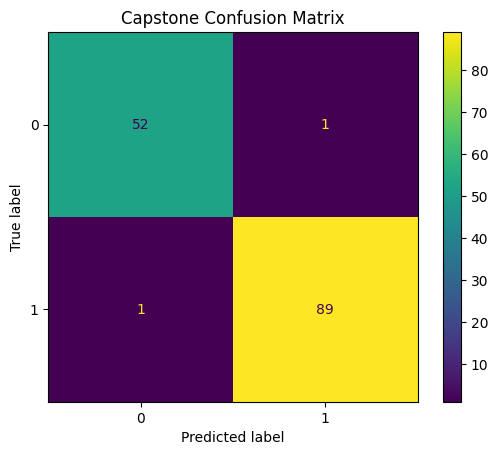

In [ ]:
y_pred = cap_model.predict(X_test_s)
y_prob = cap_model.predict_proba(X_test_s)[:, 1]

print("First 10 predicted classes:      ", y_pred[:10])
print("First 10 predicted P(class 1):   ", np.round(y_prob[:10], 3))

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:   ", recall_score(y_test, y_pred))
print("F1:       ", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)
ConfusionMatrixDisplay(cm).plot()
plt.title("Capstone Confusion Matrix")
plt.show()

First ten classes: `[1 0 1 1 0 0 0 0 0 1]`.
Probabilities: `[0.969, 0.000, 0.559, 0.939, 0.175, 0.000, 0.003, 0.001, 0.001, 1.000]`.

Look at the third one: **0.559**. A close call that still became class 1 at the 0.5 threshold. Thresholds are a choice.

Accuracy **0.986**, precision **0.989**, recall **0.989**, F1 **0.989**.

Confusion matrix:

```text
[[52  1]
 [ 1 89]]
```

52 true negatives, 89 true positives, **1** false positive, **1** false negative. Two mistakes in 143 test rows.

That is a strong result on a clean teaching dataset. It is **not** a medical device. A real clinic would have messier data, a different prevalence, and a very specific opinion about whether that 1 missed case or that 1 false alarm is the disaster.

Default `predict` uses 0.5. Try 0.3 (easier to call class 1: catch more positives, risk more false alarms) and 0.7 (stricter: fewer false alarms, risk missing positives). Before you run it, predict the direction: lower threshold → recall up, precision down? Higher threshold → the opposite?

In [ ]:
def eval_at(threshold):
    pred = (y_prob >= threshold).astype(int)
    print(
        f"threshold={threshold:.1f}  "
        f"acc={accuracy_score(y_test, pred):.3f}  "
        f"prec={precision_score(y_test, pred):.3f}  "
        f"rec={recall_score(y_test, pred):.3f}  "
        f"f1={f1_score(y_test, pred):.3f}"
    )


eval_at(0.3)
eval_at(0.5)
eval_at(0.7)

threshold=0.3  acc=0.979  prec=0.968  rec=1.000  f1=0.984
threshold=0.5  acc=0.986  prec=0.989  rec=0.989  f1=0.989
threshold=0.7  acc=0.951  prec=0.988  rec=0.933  f1=0.960


| Threshold | Accuracy | Precision | Recall | F1 |
|-----------|----------|-----------|--------|-----|
| 0.3 | 0.979 | 0.968 | **1.000** | 0.984 |
| 0.5 | 0.986 | 0.989 | 0.989 | 0.989 |
| 0.7 | 0.951 | 0.988 | **0.933** | 0.960 |

A lower threshold raised recall to **1.0** (we caught every positive) and lowered precision a bit. A higher threshold dropped recall to **0.933**. That is the tradeoff, not a bug.

If missing a positive is the disaster, you may accept more false alarms. If false alarms are the disaster, you may accept missing some positives. The metric you watch is a *choice about which mistake matters*.

If you can answer these without looking up jargon, the capstone did its job:

1. What were our features?
2. What were we trying to predict?
3. Why did we split the data?
4. What did the model learn from?
5. How did we evaluate it?
6. What kinds of mistakes did it make? (one false positive, one false negative at 0.5)
7. What would make us suspect overfitting?

## Your turn

Pick **one**. No new ideas, just reuse what you already ran. Try something. You are not going to break the notebook.

### Option A: Regression (California Housing)

Train on a **different subset of features** than you used in Section 15.
Compare MAE and R² to the full-feature model (MAE **0.533**, R² **0.576**).
Write 3-5 sentences: what changed, and does that surprise you?

### Option B: Classification (Breast Cancer)

Using the probabilities you already have, evaluate at two new thresholds of your choice (not 0.3 / 0.5 / 0.7).
Compare accuracy, precision, recall, and F1.
Write 3-5 sentences: who is helped and who is hurt by the change?

# What you now know

### Data
Examples represented as features (`X`) and targets (`y`).

### Model
A mathematical function with learnable parameters (`w`, `b`, …).

### Prediction
What the model thinks the answer is.

### Loss
How wrong that prediction is.

### Optimization
How the model improves (gradient steps you can write, or `.fit()` that hides them).

### Evaluation
Metrics on data the model did **not** train on. Accuracy, precision, recall, F1, MAE, MSE, R². Each answers a different question.

### Generalization
Whether it still works on examples it has never seen. Underfit / overfit is this idea, diagnosed with train vs test.

```text
Data → Model → Prediction → Loss → Optimization → Evaluation → Generalization
```

**Python** gave us the language. **NumPy** taught you how data is represented. **Linear algebra** taught you `y = wx + b`. **Calculus** taught you how models improve. We finally watched a weight follow a gradient. **PyTorch** gave you a loop you can see. **This notebook** showed you what the process is trying to accomplish, including the ways it quietly cheats (leakage) or lies (accuracy on an unbalanced problem).

You do not need a new personality to do this work. You need the loop, the habit of hiding test data, and the stubborn question: *what kind of mistake do I actually care about?*

## Next: Part 6. Neural Networks From Scratch

So far, libraries have done much of the machinery for us.

Next, we will build the machinery ourselves: neurons, layers, forward passes, loss, and backpropagation. You already have every idea that speech uses. Part 6 is those ideas, without the hiding.

---

**You have completed Part 5: Machine Learning Foundations.**